# Ejercicio 2: visualiza los datos

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# Ruta donde están los CSV
data_path = "Data/."

# Patrón para localizar todos los ficheros de entrenamiento
csv_files = glob.glob(os.path.join(data_path, "TankTraining_*.csv"))
print("Encontrados:", len(csv_files), "ficheros")
print("\n".join(csv_files))

Encontrados: 182 ficheros
Data/.\TankTraining_01_12_2025 16_53_57.csv
Data/.\TankTraining_01_12_2025 16_54_13.csv
Data/.\TankTraining_01_12_2025 16_55_15.csv
Data/.\TankTraining_01_12_2025 16_55_30.csv
Data/.\TankTraining_01_12_2025 16_55_50.csv
Data/.\TankTraining_01_12_2025 16_56_04.csv
Data/.\TankTraining_01_12_2025 16_56_17.csv
Data/.\TankTraining_01_12_2025 17_08_25.csv
Data/.\TankTraining_01_12_2025 17_08_48.csv
Data/.\TankTraining_01_12_2025 17_12_39.csv
Data/.\TankTraining_01_12_2025 17_13_07.csv
Data/.\TankTraining_01_12_2025 17_13_31.csv
Data/.\TankTraining_01_12_2025 17_13_52.csv
Data/.\TankTraining_02_12_2025 10_45_19.csv
Data/.\TankTraining_02_12_2025 10_45_38.csv
Data/.\TankTraining_02_12_2025 10_45_55.csv
Data/.\TankTraining_02_12_2025 10_46_21.csv
Data/.\TankTraining_02_12_2025 10_46_35.csv
Data/.\TankTraining_02_12_2025 10_46_55.csv
Data/.\TankTraining_02_12_2025 10_47_11.csv
Data/.\TankTraining_02_12_2025 10_47_35.csv
Data/.\TankTraining_02_12_2025 10_47_50.csv
Data/.

In [2]:
dfs = [pd.read_csv(f) for f in csv_files]
data = pd.concat(dfs, ignore_index=True)

print("Shape del dataset combinado:", data.shape)
data.head()

Shape del dataset combinado: (29084, 22)


,NEIGHBORHOOD_UP,NEIGHBORHOOD_DOWN,NEIGHBORHOOD_RIGHT,NEIGHBORHOOD_LEFT,NEIGHBORHOOD_DIST_UP,NEIGHBORHOOD_DIST_DOWN,NEIGHBORHOOD_DIST_RIGHT,NEIGHBORHOOD_DIST_LEFT,COMMAND_CENTER_X,COMMAND_CENTER_Y,...,AGENT_2_X,AGENT_2_Y,CAN_FIRE,HEALTH,LIFE_X,LIFE_Y,EXIT_X,EXIT_Y,time,action
0,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,27.0,27.0,1.0,2.0,11.0,5.0,3.0,21.0,0.122043,0.0
1,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,27.0,27.0,1.0,2.0,11.0,5.0,3.0,21.0,0.205221,0.0
2,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,27.0,27.0,1.0,2.0,11.0,5.0,3.0,21.0,0.303706,0.0
3,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,27.0,27.0,1.0,2.0,11.0,5.0,3.0,21.0,0.407916,0.0
4,0,1.0,2.0,1.0,0.0,0.307555,0.3085,8.307555,15.0,3.0,...,27.0,27.0,0.0,2.0,11.0,5.0,3.0,21.0,0.501813,0.0


In [3]:
action_counts = data["action"].value_counts().sort_index()
print(action_counts)

action
0.0    4003
1.0    9994
2.0    1903
3.0    7337
4.0    5665
Name: count, dtype: int64


In [4]:
# Eliminar filas donde 'action' sea NaN
data = data.dropna(subset=["action"]).copy()

# Ahora sí podemos castear a int sin problemas
data["action_int"] = data["action"].astype(int)

action_names = {
    0: "NOTHING",
    1: "MOVE_UP",
    2: "MOVE_DOWN",
    3: "MOVE_RIGHT",
    4: "MOVE_LEFT",
}

data["action_int"] = data["action"].astype(int)
data["action_name"] = data["action_int"].map(action_names)

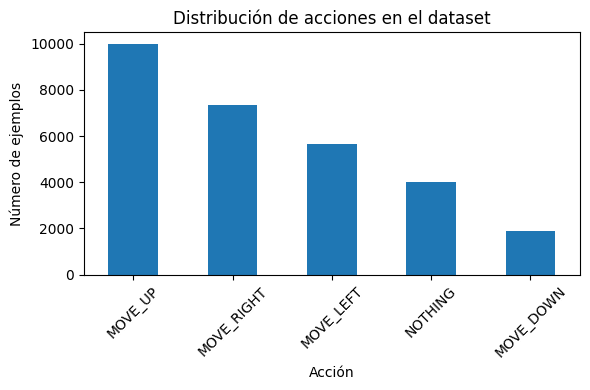

In [5]:
plt.figure(figsize=(6,4))
action_counts = data["action_name"].value_counts()

action_counts.plot(kind="bar")
plt.xlabel("Acción")
plt.ylabel("Número de ejemplos")
plt.title("Distribución de acciones en el dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Features: todo menos 'action' y la columna auxiliar 'action_int'
X = data.drop(columns=["action", "action_int", "action_name"])
y = data["action_int"]
print("Shape X:", X.shape)

Shape X: (28902, 21)


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por PC1 y PC2:",
      pca.explained_variance_ratio_)

Varianza explicada por PC1 y PC2: [0.23499514 0.10181432]


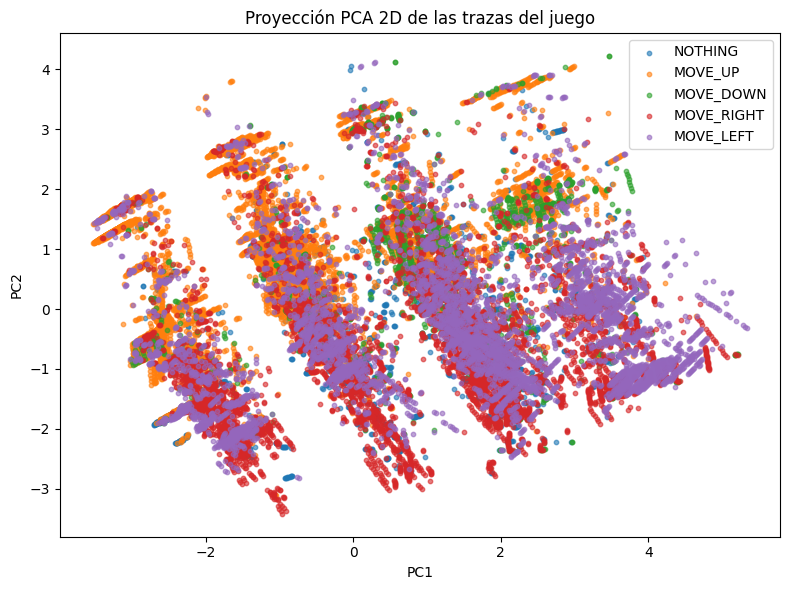

In [9]:
plt.figure(figsize=(8,6))

for action_value, name in action_names.items():
    idx = (y == action_value)
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        s=10,
        alpha=0.6,
        label=name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección PCA 2D de las trazas del juego")
plt.legend()
plt.tight_layout()
plt.show()

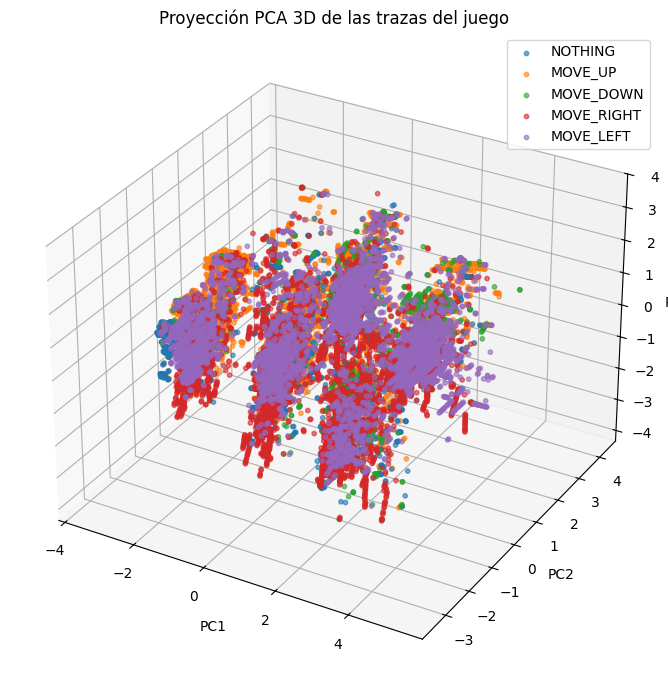

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # import necesario

pca3 = PCA(n_components=3, random_state=0)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

for action_value, name in action_names.items():
    idx = (y == action_value)
    ax.scatter(
        X_pca3[idx, 0],
        X_pca3[idx, 1],
        X_pca3[idx, 2],
        s=10,
        alpha=0.6,
        label=name
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Proyección PCA 3D de las trazas del juego")
ax.legend()
plt.tight_layout()
plt.show()


# Ejercicio 3: limpia el dataset

In [11]:
df = data.dropna().copy()

# Se aseguran tipos numéricos en los vecinos
for col in ["NEIGHBORHOOD_UP", "NEIGHBORHOOD_DOWN",
            "NEIGHBORHOOD_RIGHT", "NEIGHBORHOOD_LEFT"]:
    df[col] = pd.to_numeric(df[col])

# Acción como entero (0..4)
df["action_int"] = df["action"].astype(int)

In [12]:
cols_to_drop = [c for c in ["action_name"] if c in df.columns]
df = df.drop(columns=cols_to_drop)

In [13]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    "NEIGHBORHOOD_UP",
    "NEIGHBORHOOD_DOWN",
    "NEIGHBORHOOD_RIGHT",
    "NEIGHBORHOOD_LEFT",
]

# numeric_cols: todas las numéricas excepto acción y los vecinos (que van por OHE)
numeric_cols = [
    c for c in df.columns
    if c not in categorical_cols + ["action", "action_int"]
]

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['NEIGHBORHOOD_UP', 'NEIGHBORHOOD_DOWN', 'NEIGHBORHOOD_RIGHT', 'NEIGHBORHOOD_LEFT']
Numeric: ['NEIGHBORHOOD_DIST_UP', 'NEIGHBORHOOD_DIST_DOWN', 'NEIGHBORHOOD_DIST_RIGHT', 'NEIGHBORHOOD_DIST_LEFT', 'COMMAND_CENTER_X', 'COMMAND_CENTER_Y', 'AGENT_1_X', 'AGENT_1_Y', 'AGENT_2_X', 'AGENT_2_Y', 'CAN_FIRE', 'HEALTH', 'LIFE_X', 'LIFE_Y', 'EXIT_X', 'EXIT_Y', 'time']


In [14]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = encoder.fit_transform(df[categorical_cols])

# Numéricas como array float
X_num = df[numeric_cols].to_numpy(dtype=float)

# Dataset de entrada completo
import numpy as np
X_full = np.hstack([X_cat, X_num])

# Etiquetas
y = df["action_int"].to_numpy()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.33,
    random_state=0,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (19364, 38)  Test: (9538, 38)


In [16]:
import pandas as pd
import numpy as np

# 1) Nombres de las columnas one-hot
cat_feature_names = encoder.get_feature_names_out(categorical_cols)

# 2) DataFrames separados
X_cat_df = pd.DataFrame(X_cat, columns=cat_feature_names, index=df.index)
X_num_df = df[numeric_cols].astype(float).reset_index(drop=True)

# 3) Dataset de entrada completo como DataFrame
X_full_df = pd.concat([X_cat_df.reset_index(drop=True), X_num_df], axis=1)

print("Shape X_full_df:", X_full_df.shape)

Shape X_full_df: (28902, 38)


In [17]:
X_full = X_full_df.to_numpy()
y = df["action_int"].to_numpy()

In [18]:
df_clean = X_full_df.copy()
df_clean["action_int"] = y


df_clean.to_csv("TankTraining_clean_OHE.csv", index=False)

# Ejercicio 4: prueba diferentes modelos de Machine Learning

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cargamos el dataset ya limpio + OHE
df_ohe = pd.read_csv("TankTraining_clean_OHE.csv")

# X: todas las columnas menos la etiqueta
X = df_ohe.drop(columns=["action_int"]).to_numpy(dtype=float)
y = df_ohe["action_int"].to_numpy(dtype=int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Clases:", np.unique(y))

X shape: (28902, 38)
y shape: (28902,)
Clases: [0 1 2 3 4]


In [20]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

X_train.shape, X_test.shape

((23121, 38), (5781, 38))

In [21]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Baseline: 2 capas ocultas (por ejemplo 64 y 32 neuronas)
mlp_sklearn = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation="logistic",
    solver="adam",
    alpha=1e-6,
    learning_rate_init=0.005,
    max_iter=2000,
    random_state=0
)

mlp_sklearn.fit(X_train, y_train)

y_train_pred = mlp_sklearn.predict(X_train)
y_test_pred = mlp_sklearn.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f"MLP sklearn (logistic) - Acc train: {acc_train:.3f} Acc test: {acc_test:.3f}")

MLP sklearn (logistic) - Acc train: 0.890 Acc test: 0.798


In [22]:
import numpy as np
from MLP import MLP

n_classes = len(np.unique(y_train))

Y_train_oh = np.eye(n_classes)[y_train] # (N_train, 5)
Y_test_oh = np.eye(n_classes)[y_test]   # (N_test, 5)

In [23]:
input_dim = X_train.shape[1]
hidden_dim = 25
output_dim = n_classes

mlp_own = MLP(input_dim, hidden_dim, output_dim, seed=0, epislom=0.12)

Jhistory = mlp_own.backpropagation(
    X_train,
    Y_train_oh,
    alpha=1.0,
    lambda_=0.0,
    numIte=2000,
    verbose=200
)

Iteration      1: Cost   3.4336   
Iteration    201: Cost   1.6264   
Iteration    401: Cost   1.5531   
Iteration    601: Cost   1.4812   
Iteration    801: Cost   1.4240   
Iteration   1001: Cost   1.3829   
Iteration   1201: Cost   1.3544   
Iteration   1401: Cost   1.3334   
Iteration   1601: Cost   1.3166   
Iteration   1801: Cost   1.3031   
Iteration   2000: Cost   1.2923   


In [24]:
from sklearn.metrics import accuracy_score

# Train
a3_train = mlp_own.feedforward(X_train)[2]
y_train_pred_own = mlp_own.predict(a3_train)

# Test
a3_test = mlp_own.feedforward(X_test)[2]
y_test_pred_own = mlp_own.predict(a3_test)

acc_train_own = accuracy_score(y_train, y_train_pred_own)
acc_test_own = accuracy_score(y_test, y_test_pred_own)

print(f"MLP propio - Acc train: {acc_train_own:.3f}   Acc test: {acc_test_own:.3f}")

MLP propio - Acc train: 0.741   Acc test: 0.735


### MLPClassifier "tuneado"

In [25]:
mlp_relu = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=0.001,
    max_iter=400,
    random_state=0,
    early_stopping=True,
    n_iter_no_change=10
)

mlp_relu.fit(X_train, y_train)
y_test_pred_relu = mlp_relu.predict(X_test)
acc_test_relu = accuracy_score(y_test, y_test_pred_relu)
print(f"MLP sklearn (ReLU) - Acc test: {acc_test_relu:.3f}")

MLP sklearn (ReLU) - Acc test: 0.778


### KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    metric="minkowski",
    p=2
)

knn.fit(X_train, y_train)
y_test_pred_knn = knn.predict(X_test)
acc_test_knn = accuracy_score(y_test, y_test_pred_knn)
print(f"KNN (k=7) - Acc test: {acc_test_knn:.3f}")

### Árbol de decisión y Random Forest

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

tree_clf = DecisionTreeClassifier(
    max_depth=20,
    min_samples_leaf=5,
    random_state=0
)

tree_clf.fit(X_train, y_train)
y_test_pred_tree = tree_clf.predict(X_test)
acc_test_tree = accuracy_score(y_test, y_test_pred_tree)
print(f"Decision Tree - Acc test: {acc_test_tree:.3f}")

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=0,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)
y_test_pred_rf = rf_clf.predict(X_test)
acc_test_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"Random Forest - Acc test: {acc_test_rf:.3f}")

Decision Tree - Acc test: 0.803
Random Forest - Acc test: 0.860


### Matrices de confusión + métricas para todos los modelos

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

action_names = {
    0: "NOTHING",
    1: "MOVE_UP",
    2: "MOVE_DOWN",
    3: "MOVE_RIGHT",
    4: "MOVE_LEFT",
}
labels_order = [0,1,2,3,4]
display_labels = [action_names[i] for i in labels_order]

def eval_and_report(name, y_true, y_pred):
    print("="*60)
    print(name)
    print("="*60)
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}\n")
    print("Classification report:")
    print(classification_report(y_true, y_pred, target_names=display_labels))
    
    cm = confusion_matrix(y_true, y_pred, labels=labels_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(xticks_rotation=45)

MLP
Accuracy: 0.735

Classification report:
              precision    recall  f1-score   support

     NOTHING       0.69      0.50      0.58       801
     MOVE_UP       0.78      0.86      0.81      1999
   MOVE_DOWN       0.67      0.35      0.46       381
  MOVE_RIGHT       0.72      0.79      0.76      1467
   MOVE_LEFT       0.71      0.74      0.72      1133

    accuracy                           0.73      5781
   macro avg       0.71      0.65      0.67      5781
weighted avg       0.73      0.73      0.73      5781

MLP sklearn (logistic)
Accuracy: 0.798

Classification report:
              precision    recall  f1-score   support

     NOTHING       0.72      0.74      0.73       801
     MOVE_UP       0.84      0.86      0.85      1999
   MOVE_DOWN       0.73      0.59      0.65       381
  MOVE_RIGHT       0.79      0.81      0.80      1467
   MOVE_LEFT       0.82      0.78      0.80      1133

    accuracy                           0.80      5781
   macro avg       0.78 

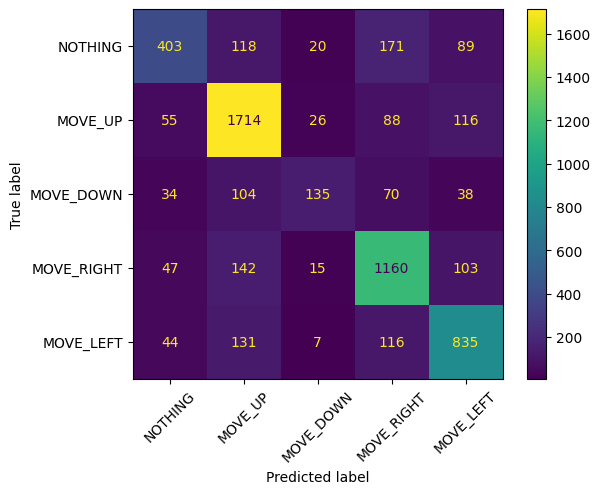

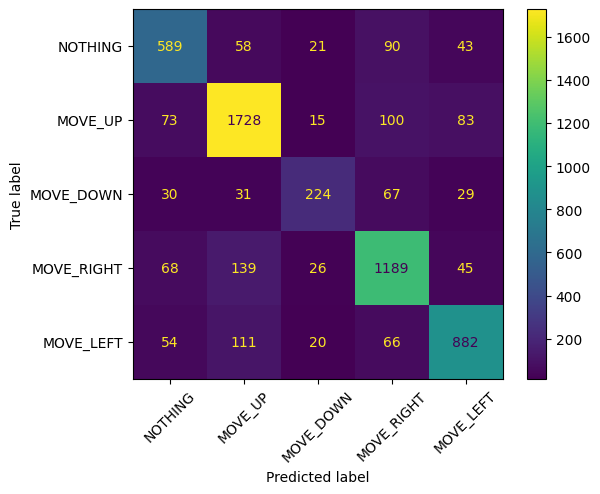

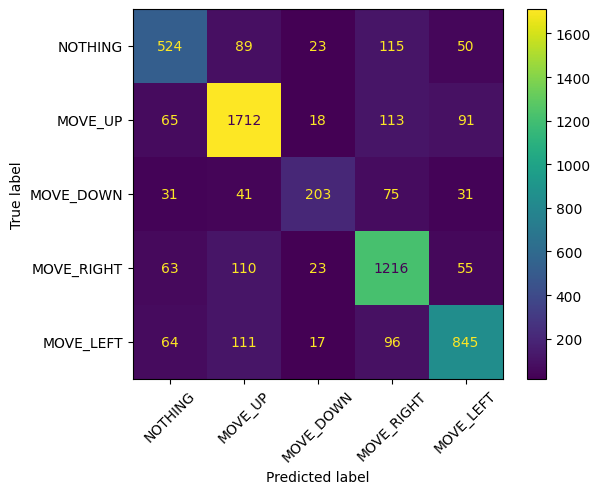

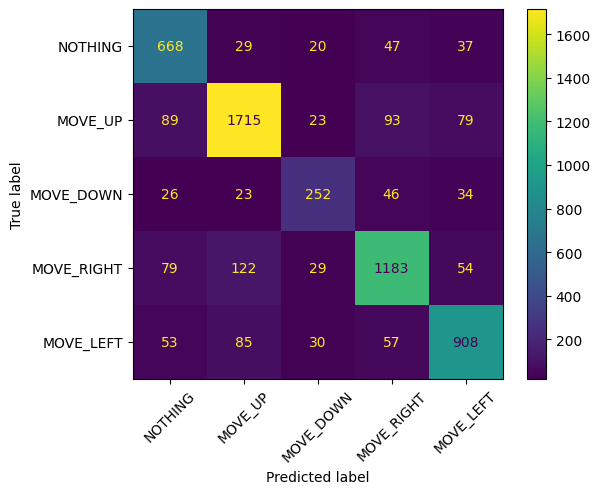

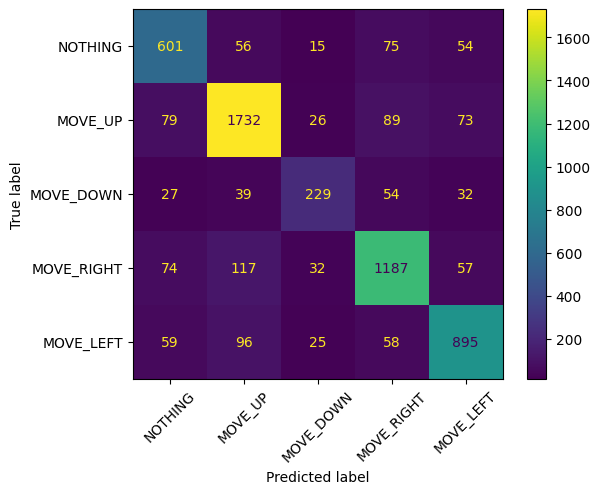

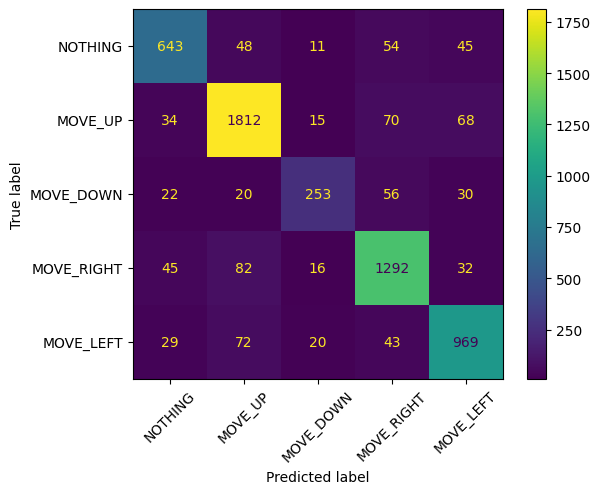

In [29]:
eval_and_report("MLP", y_test, y_test_pred_own)
eval_and_report("MLP sklearn (logistic)", y_test, y_test_pred)
eval_and_report("MLP sklearn (ReLU tuneado)", y_test, y_test_pred_relu)
eval_and_report("KNN", y_test, y_test_pred_knn)
eval_and_report("Decision Tree", y_test, y_test_pred_tree)
eval_and_report("Random Forest", y_test, y_test_pred_rf)

# Ejercicio 5: implementa el perceptrón multicapa que quieras en Unity

### Preparar y exportar el MLP final en Python

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Cargamos el dataset ya limpio + OHE
df_ohe = pd.read_csv("TankTraining_clean_OHE.csv")

X_all = df_ohe.drop(columns=["action_int"]).to_numpy(dtype=float)
y_all = df_ohe["action_int"].to_numpy(dtype=int)

print("X_all:", X_all.shape, "  y_all:", y_all.shape, "  clases:", np.unique(y_all))

# Escalador FINAL (se ajusta con TODOS los datos)
scaler_full = StandardScaler()
X_all_scaled = scaler_full.fit_transform(X_all)

# MLP FINAL
mlp_final = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation="logistic",
    solver="adam",
    alpha=1e-6,
    learning_rate_init=0.005,
    max_iter=2000,
    random_state=0
)

mlp_final.fit(X_all_scaled, y_all)

print("Accuracy entrenamiento (solo por curiosidad):",
      mlp_final.score(X_all_scaled, y_all))

X_all: (28902, 38)   y_all: (28902,)   clases: [0 1 2 3 4]
Accuracy entrenamiento (solo por curiosidad): 0.8739533596290914


### Exportar el MLP y el StandardScaler

In [32]:
from Utils import ExportAllformatsMLPSKlearn, WriteStandardScaler
import os

# 1. Definir nombres de archivo y carpeta
output_folder = "ModelExports"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Nombres para los archivos del modelo
model_name = "tank_model"
pickle_path = os.path.join(output_folder, model_name + ".pkl")
onnx_path = os.path.join(output_folder, model_name + ".onnx")
json_path = os.path.join(output_folder, model_name + ".json")
custom_path = os.path.join(output_folder, model_name + ".custom.ml") # La extensión .ml o .txt sirve

# Nombre para el archivo del Scaler
scaler_path = os.path.join(output_folder, "StandarScalerData.txt")

# 2. Exportar el Modelo (Pesos y Sesgos)
# Usamos 'mlp_final' (tu modelo) y 'X_all_scaled' (tus datos)
print("Exportando modelo...")
ExportAllformatsMLPSKlearn(
    mlp_final,      # El modelo entrenado
    X_all_scaled,   # Datos de entrada (para detectar dimensiones)
    pickle_path,
    onnx_path,
    json_path,
    custom_path     # ESTE es el importante para Unity (el custom)
)

# 3. Exportar el Scaler (Media y Desviación)
# Pasamos la media (mean_) y la desviación estándar (scale_)
print("Exportando scaler...")
WriteStandardScaler(
    scaler_path, 
    scaler_full.mean_, 
    scaler_full.scale_
)

print(f"¡Listo! Archivos guardados en la carpeta '{output_folder}'.")
print(f"Copia '{os.path.basename(custom_path)}' y 'StandarScalerData.txt' al proyecto de Unity.")

ModuleNotFoundError: No module named 'skl2onnx'